# Forced Damped Harmonic Oscillator

## Objective
To numerically solve the equation of a forced damped oscillator and study:
- Transient and steady-state behavior
- Resonance phenomenon
- Dependence of amplitude on driving frequency

---

## Equation of Motion

The system is governed by:

$$
\frac{d^2x}{dt^2} + 2\beta \frac{dx}{dt} + \omega_0^2 x = F_0 \cos(\omega t)
$$

where:
- $\beta$ = damping coefficient  
- $\omega_0$ = natural frequency  
- $F_0$ = driving force amplitude  
- $\omega$ = driving frequency  

---

## Conversion to First-Order System

Let:
$$
v = \frac{dx}{dt}
$$

Then:

$$
\frac{dx}{dt} = v
$$

$$
\frac{dv}{dt} = F_0 \cos(\omega t) - 2\beta v - \omega_0^2 x
$$

---

## Euler Method

We approximate derivatives using:

$$
x_{n+1} = x_n + v_n \Delta t
$$

$$
v_{n+1} = v_n + a_n \Delta t
$$

where:

$$
a_n = F_0 \cos(\omega t_n) - 2\beta v_n - \omega_0^2 x_n
$$

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Given parameters
F0 = 1
w0 = 2.5
beta = 0.5

# Time setup
dt = 0.01
t_max = 100
t = np.arange(0, t_max, dt)

# Explanation of the Code

## Numerical Solver

The function `solve_oscillator(omega)` numerically integrates the system using Euler's method.

---

## Step-by-Step Process

At each time step:

### 1. Compute acceleration
$$
a = F_0 \cos(\omega t) - 2\beta v - \omega_0^2 x
$$

---

### 2. Update position
$$
x \leftarrow x + v \Delta t
$$

---

### 3. Update velocity
$$
v \leftarrow v + a \Delta t
$$

---

### 4. Store results
The position $x(t)$ is stored for plotting.

---

## Initial Conditions

$$
x(0) = 0, \quad v(0) = 1
$$

---

## Time Discretization

- Time step: $\Delta t$
- Simulation duration: $t \in [0, 100]$

In [20]:
def solve_oscillator(omega, x0=0, v0=1):
    x = x0
    v = v0

    xs = []

    for ti in t:
        a = F0*np.cos(omega*ti) - 2*beta*v - w0**2*x

        # Euler update
        x += v * dt
        v += a * dt

        xs.append(x)

    return np.array(xs)

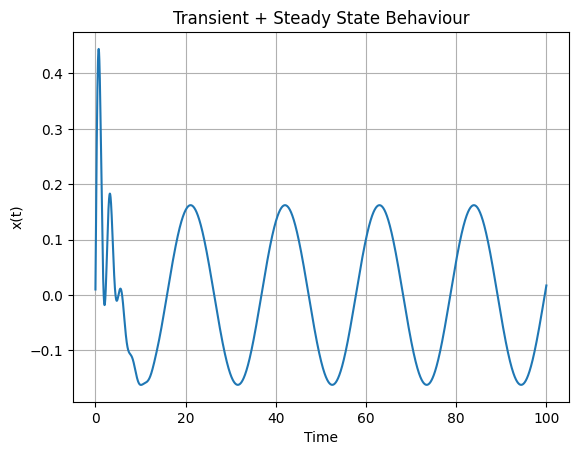

In [21]:
omega = 0.3

x = solve_oscillator(omega)

plt.figure()
plt.plot(t, x)
plt.title("Transient + Steady State Behaviour")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.grid()
plt.show()

# Transient and Steady-State Behaviour

Initially, the system exhibits **transient behavior**, which depends on initial conditions.

Due to damping:
- The transient part decays over time
- The system eventually reaches a **steady-state oscillation**

The steady-state motion is governed by the driving force.

---

## Key Observation

- Early time: irregular motion (transient)
- Later time: periodic motion at frequency $\omega$

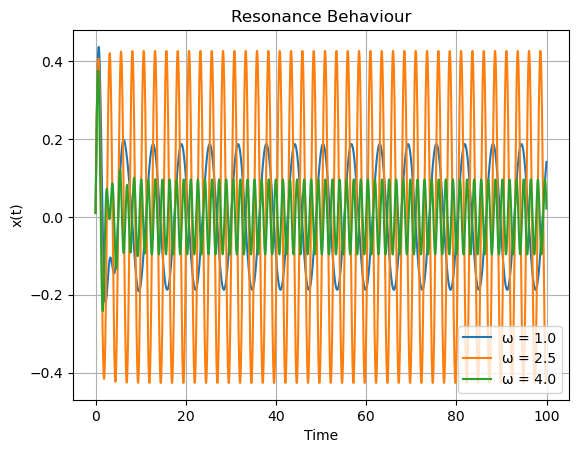

In [16]:
omegas = [1.0,w0,4.0]  # less, equal, greater

plt.figure()

for omega in omegas:
    x = solve_oscillator(omega)
    plt.plot(t, x, label=f"ω = {omega}")

plt.title("Resonance Behaviour")
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.legend()
plt.grid()
plt.show()

# Resonance Phenomenon

Resonance occurs when the driving frequency $\omega$ is close to the natural frequency $\omega_0$.

---

## Behaviour

- $\omega < \omega_0$: small amplitude
- $\omega \approx \omega_0$: large amplitude (resonance)
- $\omega > \omega_0$: amplitude decreases

---

## Effect of Damping

Due to damping, the resonance peak occurs at:

$$
\omega = \sqrt{\omega_0^2 - 2\beta^2}
$$

which is slightly less than $\omega_0$.

In [17]:
def get_amplitude(omega):
    x = solve_oscillator(omega)

    # Ignore transient (last part only)
    steady = x[int(0.7*len(x)):]
    
    return np.max(np.abs(steady))

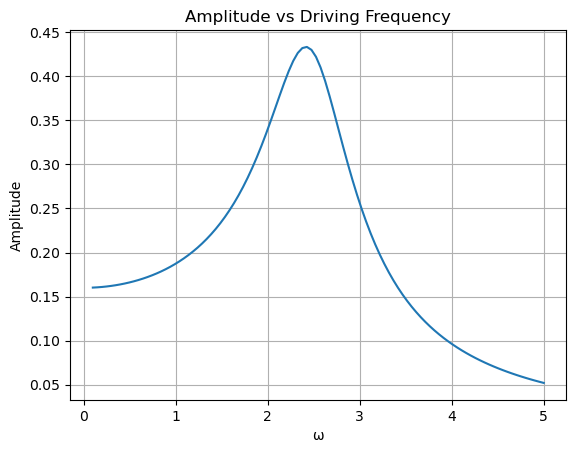

In [19]:
omega_vals = np.linspace(0.1, 5, 100)
amplitudes = []

for omega in omega_vals:
    amplitudes.append(get_amplitude(omega))

plt.figure()
plt.plot(omega_vals, amplitudes)

plt.title("Amplitude vs Driving Frequency")
plt.xlabel("ω")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Amplitude vs Driving Frequency

The steady-state amplitude is obtained by taking the maximum value of $|x(t)|$ after the transient has decayed.

---

## Procedure

1. Solve the system for different values of $\omega$
2. Ignore initial transient portion
3. Compute:
$$
A = \max |x(t)|
$$

---

## Observation

- The amplitude vs frequency graph shows a **peak**
- This peak corresponds to the **resonance frequency**

---

## Conclusion

- The system exhibits resonance at a frequency slightly less than $\omega_0$
- Damping reduces the amplitude and shifts the peak